In [ ]:
# BANK LOAN ANALYSIS REPORT

In [ ]:
### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px



In [ ]:
df=pd.read_excel("C:/Users/dhana/Desktop/Madhavan/Data Processing and Business Analyst/python/Projects/Completed/Bank loan/financial_loan.xlsx")



In [ ]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [ ]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [ ]:
### Metadata of Data

In [ ]:
print("No. of rows: ", df.shape[0])

No. of rows:  38576


In [ ]:
print("No. of columns: ", df.shape[1])

No. of columns:  24


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  str           
 2   application_type       38576 non-null  str           
 3   emp_length             38576 non-null  str           
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  str           
 6   home_ownership         38576 non-null  str           
 7   issue_date             38576 non-null  datetime64[us]
 8   last_credit_pull_date  38576 non-null  datetime64[us]
 9   last_payment_date      38576 non-null  datetime64[us]
 10  loan_status            38576 non-null  str           
 11  next_payment_date      38576 non-null  datetime64[us]
 12  member_id              38576 non-null  int64         
 13  purpose     

In [ ]:
### Datatypes

In [ ]:
df.dtypes

id                                int64
address_state                       str
application_type                    str
emp_length                          str
emp_title                        object
grade                               str
home_ownership                      str
issue_date               datetime64[us]
last_credit_pull_date    datetime64[us]
last_payment_date        datetime64[us]
loan_status                         str
next_payment_date        datetime64[us]
member_id                         int64
purpose                             str
sub_grade                           str
term                                str
verification_status                 str
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [ ]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007,2021-06-08 13:36:34.193280,2021-06-26 09:52:08.909166,2021-07-26 20:42:20.605557,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [ ]:
### Total Loan Applications

In [ ]:
total_loan_applications = df['id'].count()
print("Total Loan Applications: ", total_loan_applications)



Total Loan Applications:  38576


In [ ]:
### MTD Total Loan Applications

In [ ]:
latest_issue_date=df['issue_date'].max()
latest_issue_year=latest_issue_date.year
latest_issue_month=latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_issue_year) & (df['issue_date'].dt.month == latest_issue_month)]
mtd_loan_applications =  mtd_data['id'].count()
print(f"MTD Loan Applications (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_applications}")



MTD Loan Applications (for December 2021): 4314


In [ ]:
### Total Funded Amount

In [ ]:
# %%
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_in_millions = total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M". format(total_funded_amount_in_millions))



Total Funded Amount: $435.76M


In [ ]:
### MTD Total Funded Amount

In [ ]:
latest_issue_Date= df['issue_date'].max()
latest_issue_year = latest_issue_Date.year
latest_issue_month = latest_issue_Date.month

mtd_data= df[(df['issue_date'].dt.year == latest_issue_year) & (df['issue_date'].dt.month == latest_issue_month)]
mtd_Total_Funded_Amount = mtd_data['loan_amount'].sum()
mtd_Total_Funded_Amount_in_millions = mtd_Total_Funded_Amount/1000000
print("MTD Total Funded Amount: ${:.2f}M". format(mtd_Total_Funded_Amount_in_millions))



MTD Total Funded Amount: $53.98M


In [ ]:
### Total Amount Received

In [ ]:
total_amount_received = df['total_payment'].sum()
total_amount_received_in_millions = total_amount_received/1000000
print("Total Amount Received: ${:.2f}M".format(total_amount_received_in_millions))



Total Amount Received: $473.07M


In [ ]:
### MTD Total Amount Received

In [ ]:
latest_issue_date= df['issue_date'].max()
latest_issue_year=latest_issue_date.year
latest_issue_month = latest_issue_date.month

mtd_data= df[(df['issue_date'].dt.year == latest_issue_year) & (df['issue_date'].dt.month == latest_issue_month)]
mtd_total_amount_received = mtd_data['total_payment'].sum()
mtd_total_amount_received_in_millions = mtd_total_amount_received/1000000
print("MTD Total Amount Received: ${:.2f}M".format(mtd_total_amount_received_in_millions))



MTD Total Amount Received: $58.07M


In [ ]:
### Average Interest Rate

In [ ]:
average_interest_rate = df['int_rate'].mean()*100
print("Average Interest Rate: {:.2f}%".format(average_interest_rate))



Average Interest Rate: 12.05%


In [ ]:
### Average Debt to Income Ratio(DTI)

In [ ]:
average_dti= df['dti'].mean()*100
print("Average Debt to Income Ratio(DTI): {:.2f}%".format(average_dti))



Average Debt to Income Ratio(DTI): 13.33%


In [ ]:
### Good Loan Metrics

In [ ]:
# %%
# %%
total_loan_applications= df['id'].count()
good_loans = df[df['loan_status'].isin(['Current','Fully Paid'])]

total_good_loan_applications = good_loans['id'].count()

total_good_loan_funded = good_loans['loan_amount'].sum()
total_good_loan_funded_Millions = total_good_loan_funded/1000000

total_good_loan_received = good_loans['total_payment'].sum()
total_good_loan_received_Millions = total_good_loan_received/1000000

good_loan_percentage = total_good_loan_applications/total_loan_applications *100

print("Total Loan Applications: ", total_loan_applications)
print("Total Good Loan Applications: ", total_good_loan_applications)
print("Good Loan Percentage: {:.2f}%".format(good_loan_percentage))
print("Total Good Loan Funded: {:.2f}M".format(total_good_loan_funded_Millions))
print("Total Good Loan Received: {:.2f}M".format(total_good_loan_received_Millions))




Total Loan Applications:  38576
Total Good Loan Applications:  33243
Good Loan Percentage: 86.18%
Total Good Loan Funded: 370.22M
Total Good Loan Received: 435.79M


In [ ]:
### Bad Loan Metrics

In [ ]:
total_loan_applications= df['id'].count()
bad_loans = df[df['loan_status'].isin(['Charged Off'])]

total_bad_loan_applications = bad_loans['id'].count()

total_bad_loan_funded = bad_loans['loan_amount'].sum()
total_bad_loan_funded_Millions = total_bad_loan_funded/1000000

total_bad_loan_received = bad_loans['total_payment'].sum()
total_bad_loan_received_Millions = total_bad_loan_received/1000000

bad_loan_percentage = total_bad_loan_applications/total_loan_applications *100

print("Total Loan Applications: ", total_loan_applications)
print("Total Bad Loan Applications: ", total_bad_loan_applications)
print("Bad Loan Percentage: {:.2f}%".format(bad_loan_percentage))
print("Total Bad Loan Funded: {:.2f}M".format(total_bad_loan_funded_Millions))
print("Total Bad Loan Received: {:.2f}M".format(total_bad_loan_received_Millions))




Total Loan Applications:  38576
Total Bad Loan Applications:  5333
Bad Loan Percentage: 13.82%
Total Bad Loan Funded: 65.53M
Total Bad Loan Received: 37.28M


In [ ]:
### Monthly Trends by Issue Date for Total Funded Amount

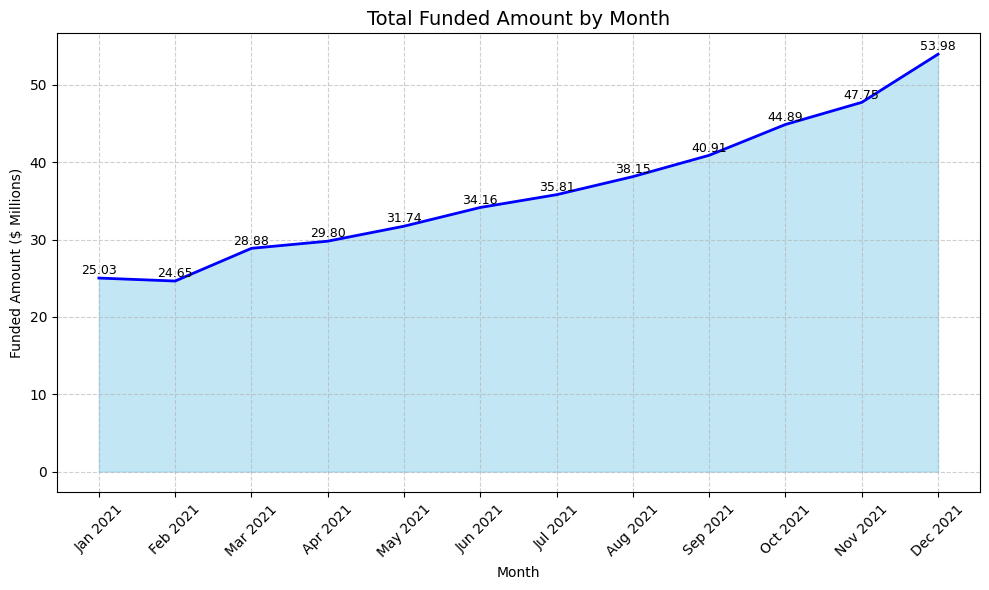

In [ ]:
# %%
df=df.sort_values('issue_date')
df['Month_name']= df['issue_date'].dt.strftime('%b %Y')
monthly_funded= df.groupby('Month_name',sort=False)['loan_amount'].sum()
monthly_funded= monthly_funded/1000000
monthly_funded = monthly_funded.reset_index(name='loan_amount_millions')

plt.figure(figsize= (10,6))
plt.fill_between(monthly_funded['Month_name'],monthly_funded['loan_amount_millions'], color='skyblue', alpha=0.5)
plt.plot(monthly_funded['Month_name'],monthly_funded['loan_amount_millions'], color='blue',linewidth = 2)

for i, row in monthly_funded.iterrows():
    plt.text(i, row['loan_amount_millions']+0.1, f"{row['loan_amount_millions']:.2f}",ha="center", va='bottom',fontsize=9, rotation=0, color = 'black')

plt.title('Total Funded Amount by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel("Funded Amount ($ Millions)")
plt.xticks(ticks=range(len(monthly_funded)), labels= monthly_funded['Month_name'],rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




In [ ]:
### Monthly Trends by Issue Date for Total Received Amount

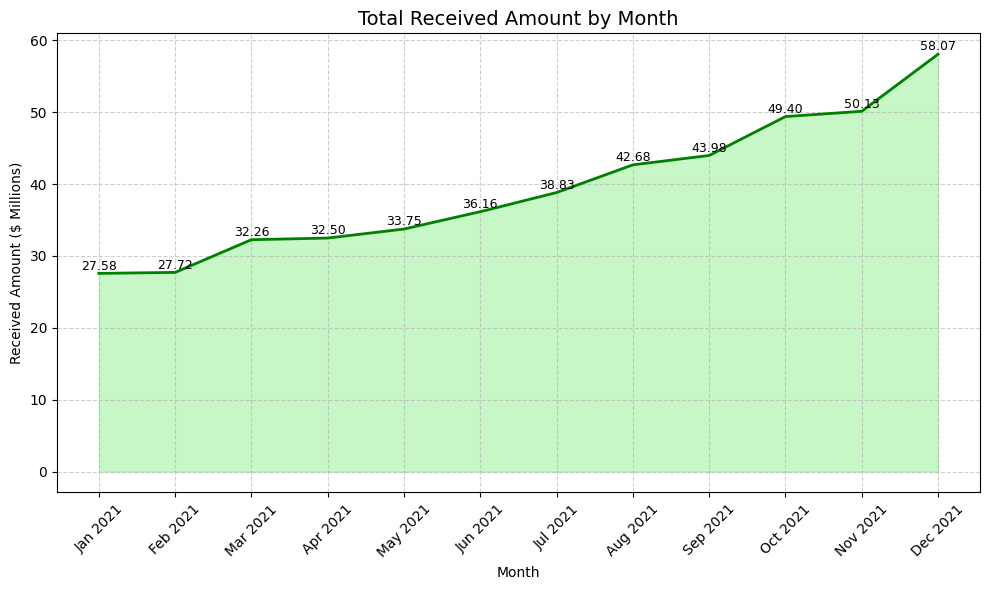

In [ ]:
df=df.sort_values('issue_date')
df['Month_name']= df['issue_date'].dt.strftime('%b %Y')
monthly_received= df.groupby('Month_name',sort=False)['total_payment'].sum()
monthly_received= monthly_received/1000000
monthly_received = monthly_received.reset_index(name='received_amount_millions')

plt.figure(figsize= (10,6))
plt.fill_between(monthly_received['Month_name'],monthly_received['received_amount_millions'], color='lightgreen', alpha=0.5)
plt.plot(monthly_received['Month_name'],monthly_received['received_amount_millions'], color='green',linewidth = 2)

for i, row in monthly_received.iterrows():
    plt.text(i, row['received_amount_millions']+0.1, f"{row['received_amount_millions']:.2f}",ha="center", va='bottom',fontsize=9, rotation=0, color = 'black')

plt.title('Total Received Amount by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel("Received Amount ($ Millions)")
plt.xticks(ticks=range(len(monthly_received)), labels= monthly_received['Month_name'],rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [ ]:
### Monthly Trends by Issue Date for Total Loan Applications

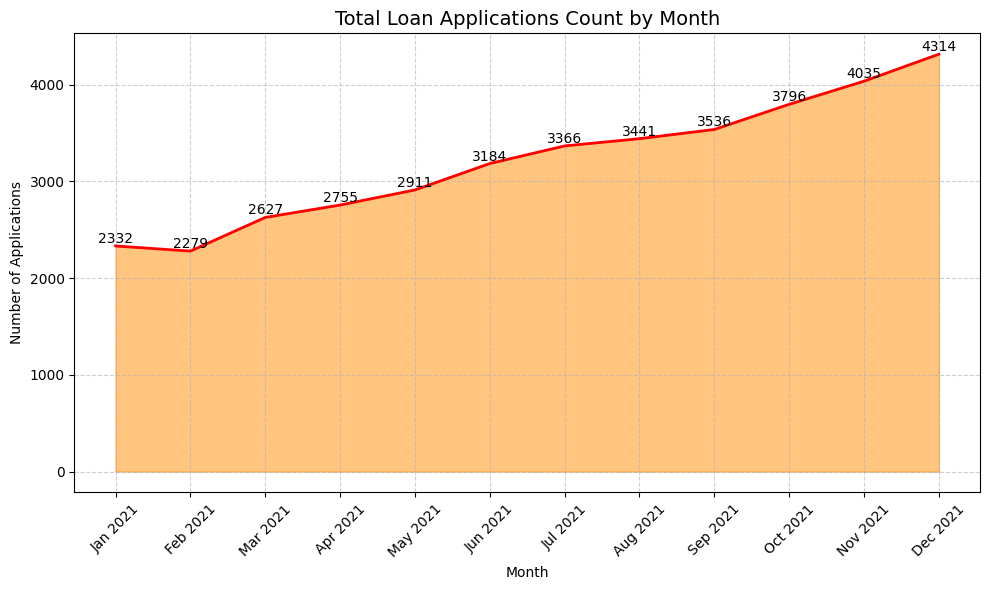

In [ ]:
df=df.sort_values('issue_date')
df['Month_name']= df['issue_date'].dt.strftime('%b %Y')
monthly_applications= df.groupby('Month_name',sort=False)['id'].count()
monthly_applications = monthly_applications.reset_index(name='Loan Applications Count')

plt.figure(figsize= (10,6))
plt.fill_between(monthly_applications['Month_name'],monthly_applications['Loan Applications Count'], color='darkorange', alpha=0.5)
plt.plot(monthly_applications['Month_name'],monthly_applications['Loan Applications Count'], color='red',linewidth = 2)

for i, y in enumerate(monthly_applications['Loan Applications Count']):
    plt.text(i, y + 0.1, f"{y:.0f}", ha="center", va='bottom')

plt.title('Total Loan Applications Count by Month', fontsize = 14)
plt.xlabel('Month')
plt.ylabel("Number of Applications")
plt.xticks(ticks=range(len(monthly_applications)), labels= monthly_applications['Month_name'],rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [ ]:
### Regional Analysis by State for Total Funded Amount

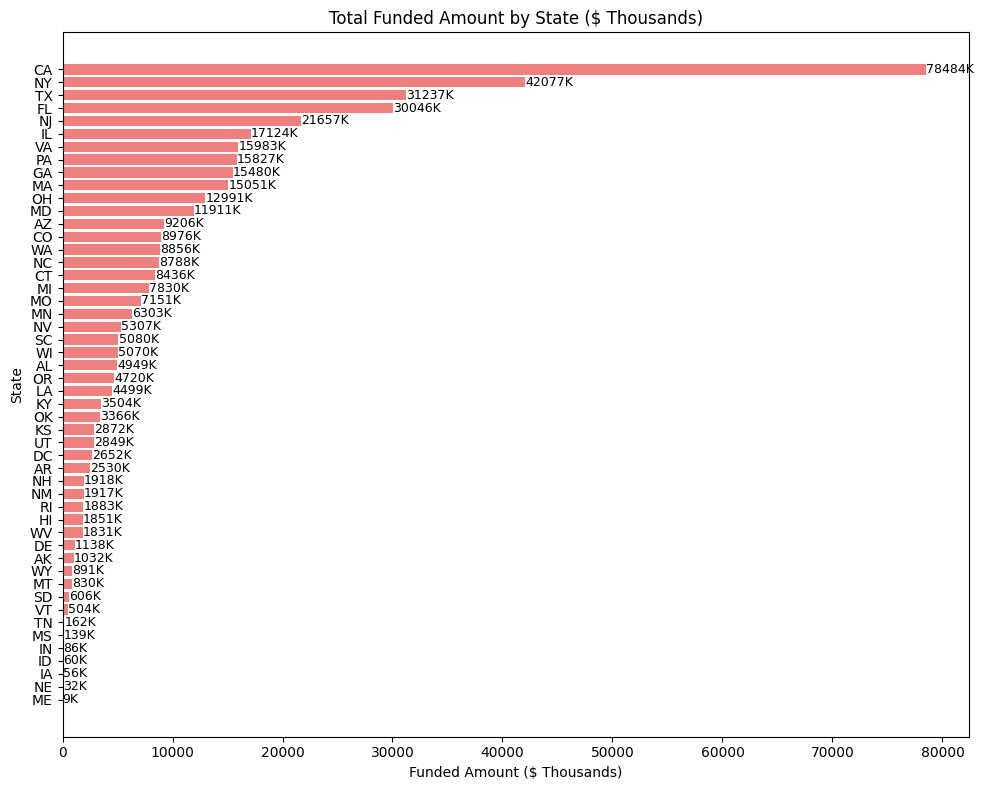

In [ ]:
state_funded= df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funded_thousands= state_funded/1000

plt.figure(figsize= (10,8))
bars= plt.barh(state_funded_thousands.index, state_funded_thousands.values, color= 'lightcoral')

for bar in bars:
    width= bar.get_width()
    plt.text(width+10, bar.get_y()+bar.get_height() /2, f"{width:.0f}K",ha="left", va='center',fontsize=9)

plt.title('Total Funded Amount by State ($ Thousands)')
plt.xlabel('Funded Amount ($ Thousands)')
plt.ylabel("State")
plt.tight_layout()
plt.show()



In [ ]:
### Regional Analysis by State for Total Received Amount

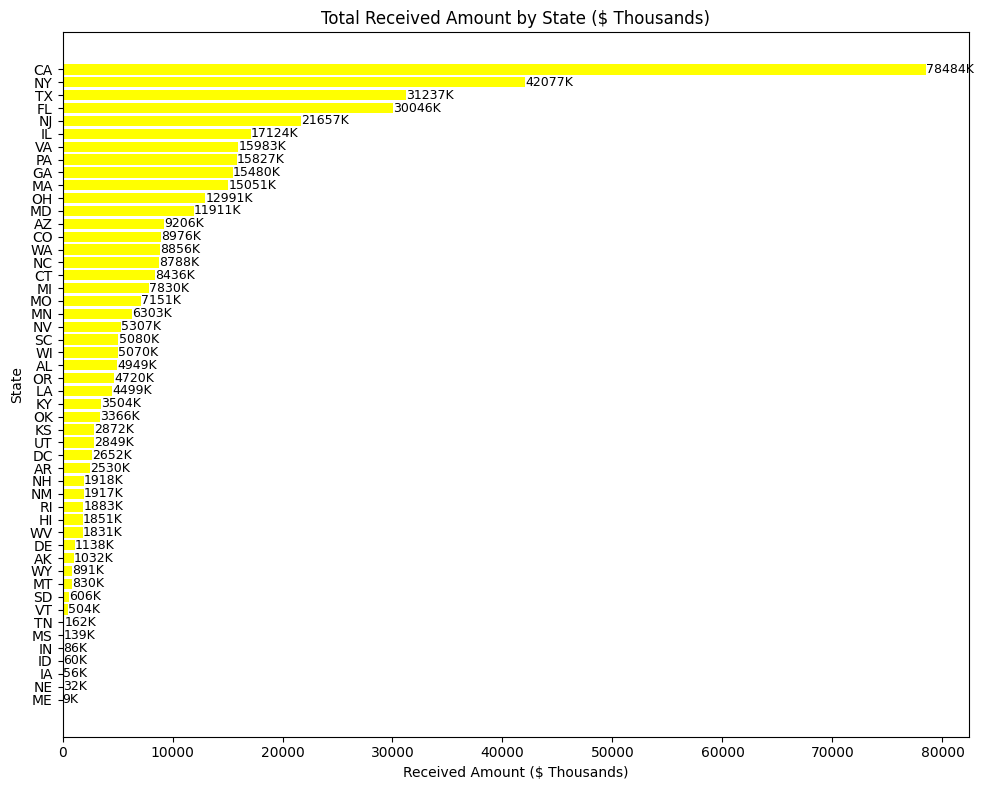

In [ ]:
# %%
# %%
state_total_received= df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_total_received_thousands= state_funded/1000

plt.figure(figsize= (10,8))
bars= plt.barh(state_total_received_thousands.index, state_total_received_thousands.values, color= 'yellow')

for bar in bars:
    width= bar.get_width()
    plt.text(width+10, bar.get_y()+bar.get_height() /2, f"{width:.0f}K",ha="left", va='center',fontsize=9)

plt.title('Total Received Amount by State ($ Thousands)')
plt.xlabel('Received Amount ($ Thousands)')
plt.ylabel("State")
plt.tight_layout()
plt.show()



In [ ]:
### Regional Analysis by State for Total Loan Applications

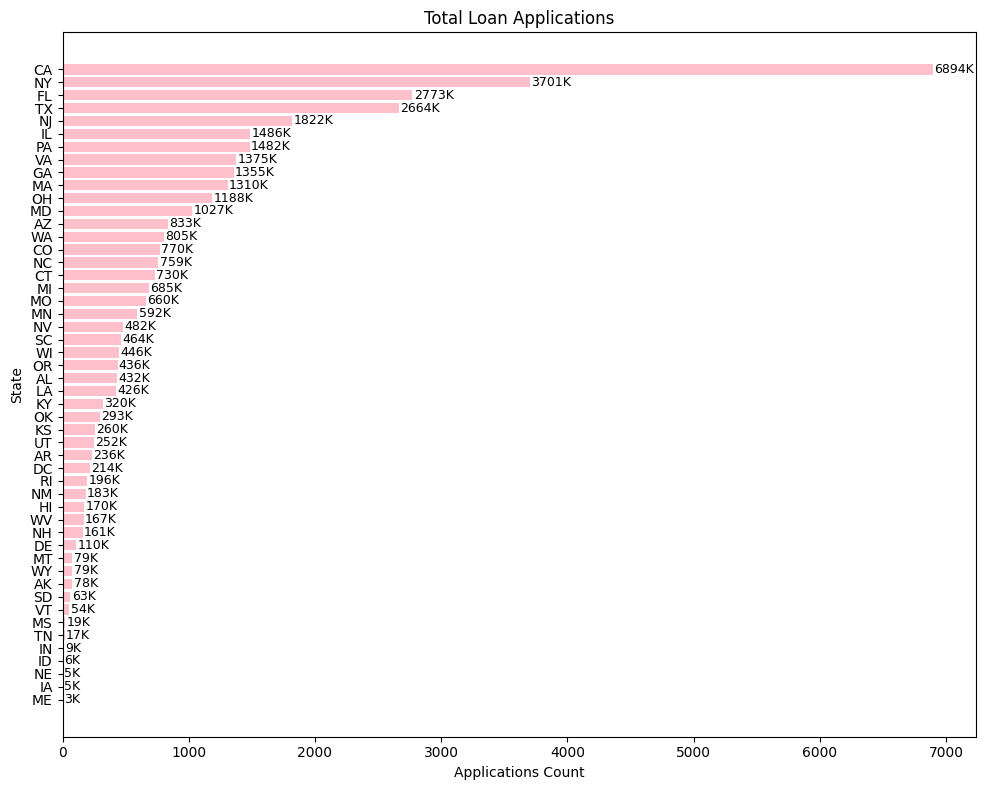

In [ ]:
state_total_applications= df.groupby('address_state')['id'].count().sort_values(ascending=True)

plt.figure(figsize= (10,8))
bars= plt.barh(state_total_applications.index, state_total_applications.values, color= 'pink')

for bar in bars:
    width= bar.get_width()
    plt.text(width+10, bar.get_y()+bar.get_height() /2, f"{width:.0f}K",ha="left", va='center',fontsize=9)

plt.title('Total Loan Applications')
plt.xlabel('Applications Count')
plt.ylabel("State")
plt.tight_layout()
plt.show()



In [ ]:
### Loan Term Analysis for Total Funded Amount

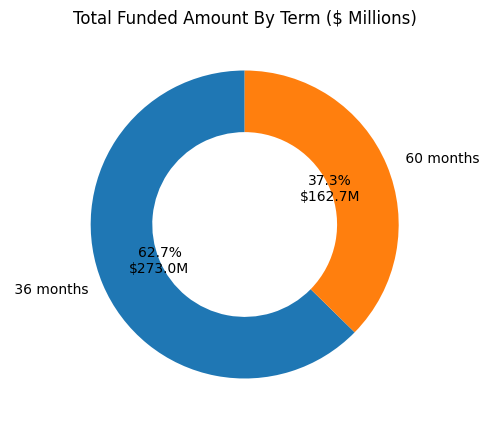

In [ ]:
funded_by_term = df.groupby('term')['loan_amount'].sum()
funded_by_term_millions = funded_by_term/1000000

plt.figure(figsize=(5,5))
plt.pie(funded_by_term_millions, labels=funded_by_term_millions.index, autopct= lambda p:f"{p:.1f}%\n${p*funded_by_term_millions.sum()/100:.1f}M", startangle = 90, wedgeprops={'width':0.4})
plt.title("Total Funded Amount By Term ($ Millions)")
plt.show()



In [ ]:
### Loan Term Analysis for Total Received Amount

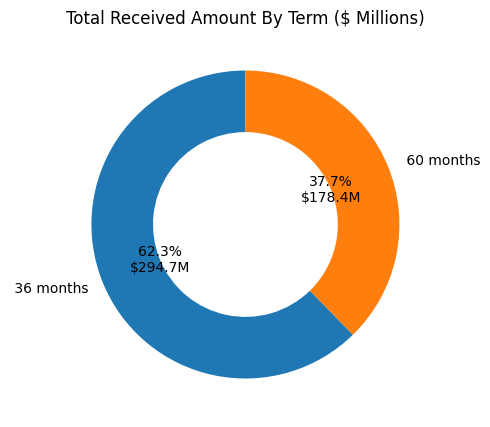

In [ ]:
received_by_term = df.groupby('term')['total_payment'].sum()
received_by_term_millions = received_by_term/1000000

plt.figure(figsize=(5,5))
plt.pie(received_by_term_millions, labels=received_by_term_millions.index, autopct= lambda p:f"{p:.1f}%\n${p*received_by_term_millions.sum()/100:.1f}M", startangle = 90, wedgeprops={'width':0.4})
plt.title("Total Received Amount By Term ($ Millions)")
plt.show()



In [ ]:
### Loan Term Analysis for Total Loan Applications

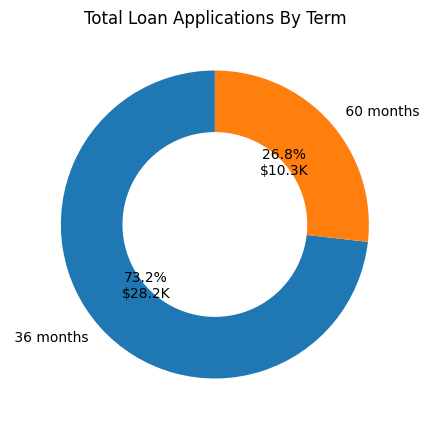

In [ ]:
# %%
total_applications_by_term = df.groupby('term')['id'].count()
total_applications_by_term_thousands = total_applications_by_term/1000

plt.figure(figsize=(5,5))
plt.pie(total_applications_by_term_thousands, labels=total_applications_by_term_thousands.index, autopct= lambda p:f"{p:.1f}%\n${p*total_applications_by_term_thousands.sum()/100:.1f}K", startangle = 90, wedgeprops={'width':0.4})
plt.title("Total Loan Applications By Term")
plt.show()



In [ ]:
### Employee Length Analysis for Total Funded Amount

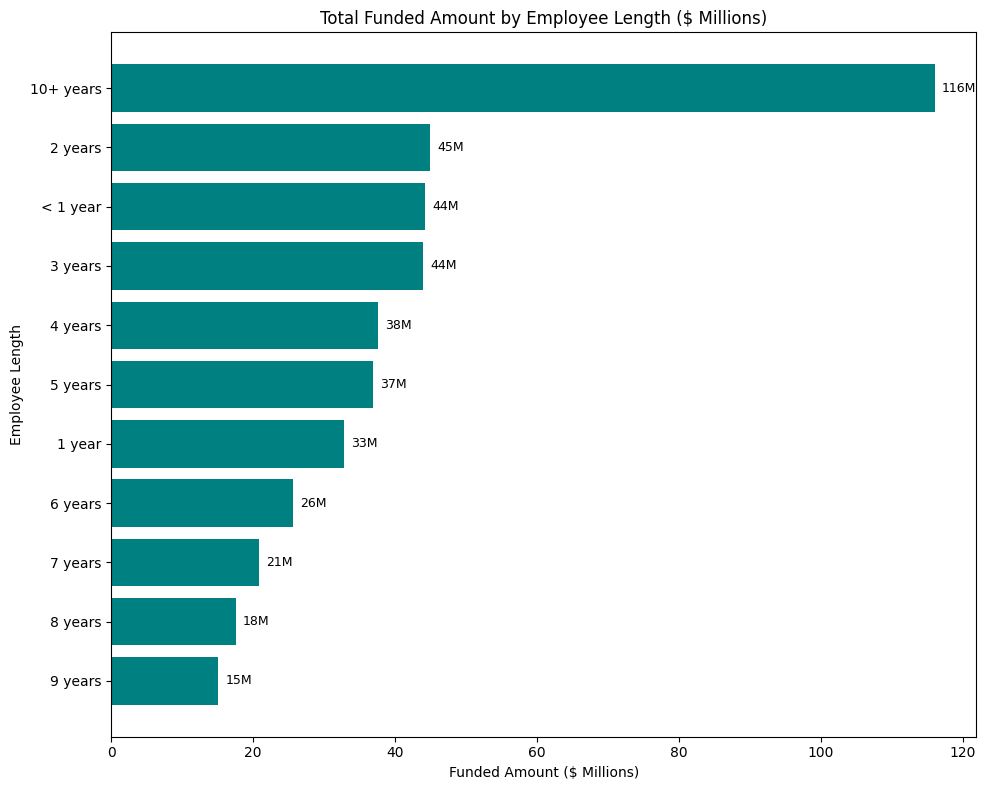

In [ ]:
funded_by_emp_len = df.groupby('emp_length')['loan_amount'].sum().sort_values()
funded_by_emp_len_millions = funded_by_emp_len/1000000

plt.figure(figsize= (10,8))
bars= plt.barh(funded_by_emp_len_millions.index, funded_by_emp_len_millions.values, color= 'teal')

for bar in bars:
    width= bar.get_width()
    plt.text(width+1, bar.get_y()+bar.get_height() /2, f"{width:.0f}M",ha="left", va='center',fontsize=9)

plt.title('Total Funded Amount by Employee Length ($ Millions)')
plt.xlabel('Funded Amount ($ Millions)')
plt.ylabel("Employee Length")
plt.tight_layout()
plt.show()



In [ ]:
### Employee Length Analysis for Total Received Amount

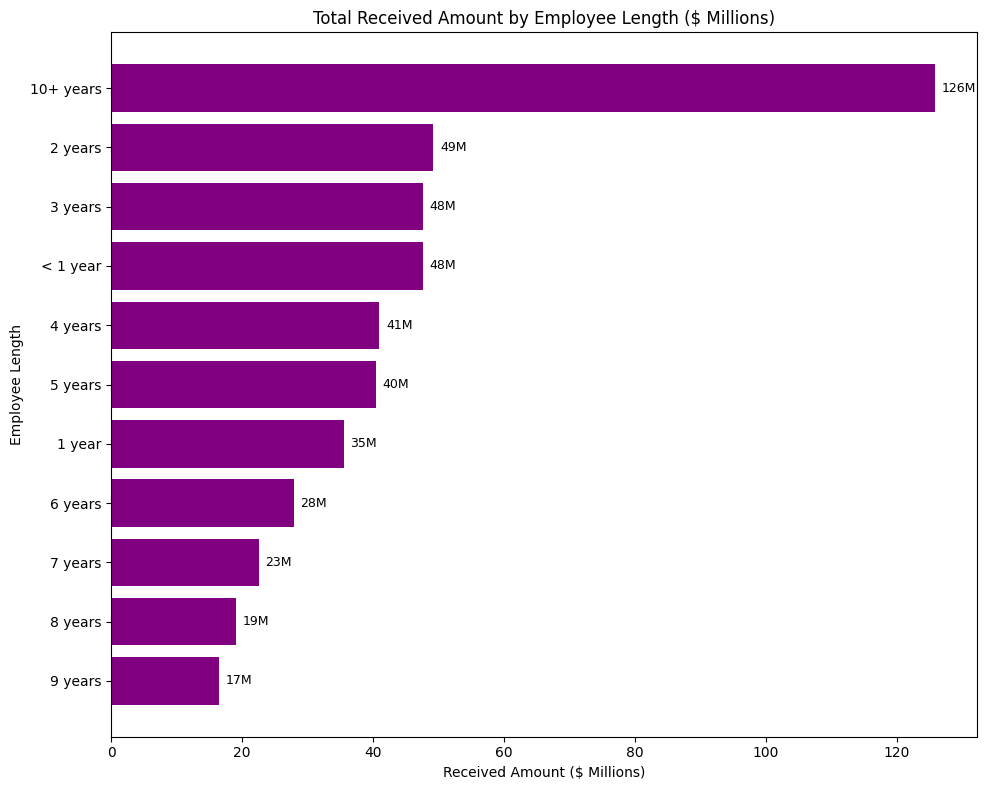

In [ ]:
received_amount_by_emp_len = df.groupby('emp_length')['total_payment'].sum().sort_values()
received_amount_by_emp_len_millions = received_amount_by_emp_len/1000000

plt.figure(figsize= (10,8))
bars= plt.barh(received_amount_by_emp_len_millions.index, received_amount_by_emp_len_millions.values, color= 'purple')

for bar in bars:
    width= bar.get_width()
    plt.text(width+1, bar.get_y()+bar.get_height() /2, f"{width:.0f}M",ha="left", va='center',fontsize=9)

plt.title('Total Received Amount by Employee Length ($ Millions)')
plt.xlabel('Received Amount ($ Millions)')
plt.ylabel("Employee Length")
plt.tight_layout()
plt.show()



In [ ]:
### Employee Length Analysis for Total Loan Applications

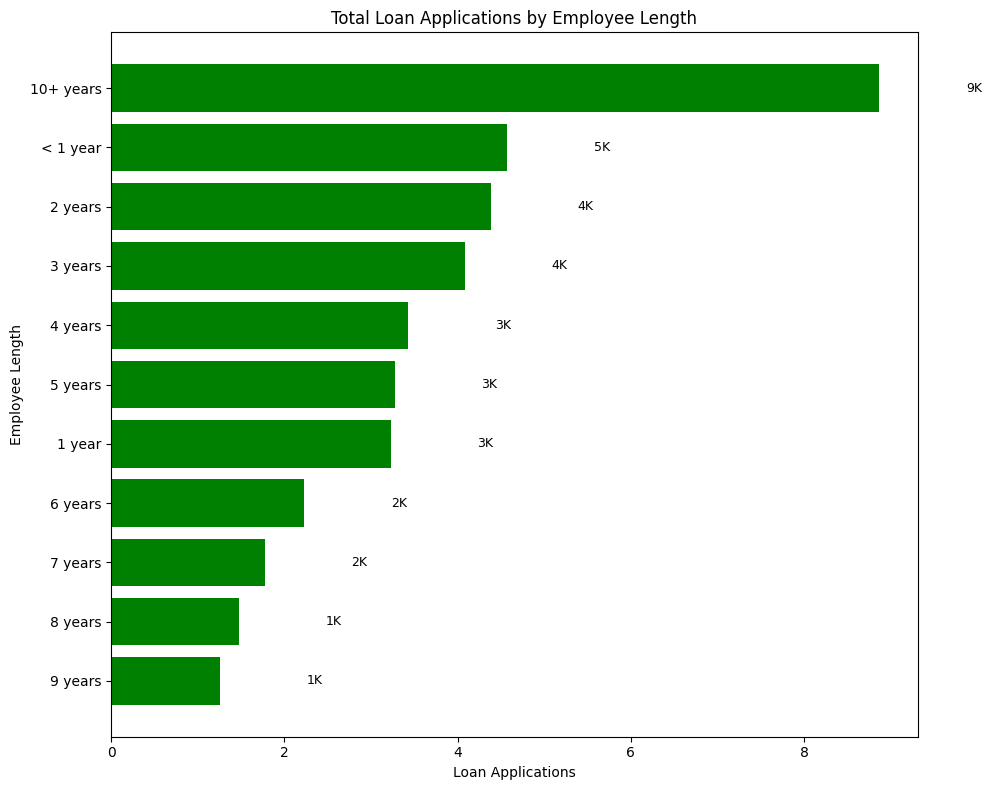

In [ ]:

# %%
total_applications_by_emp_len = df.groupby('emp_length')['id'].count().sort_values()
received_amount_by_emp_len_thousands = total_applications_by_emp_len/1000

plt.figure(figsize= (10,8))
bars= plt.barh(received_amount_by_emp_len_thousands.index, received_amount_by_emp_len_thousands.values, color= 'green')

for bar in bars:
    width= bar.get_width()
    plt.text(width+1, bar.get_y()+bar.get_height() /2, f"{width:.0f}K",ha="left", va='center',fontsize=9)

plt.title('Total Loan Applications by Employee Length')
plt.xlabel('Loan Applications')
plt.ylabel("Employee Length")
plt.tight_layout()
plt.show()



In [ ]:


### Loan Purpose for Total Funded Amount

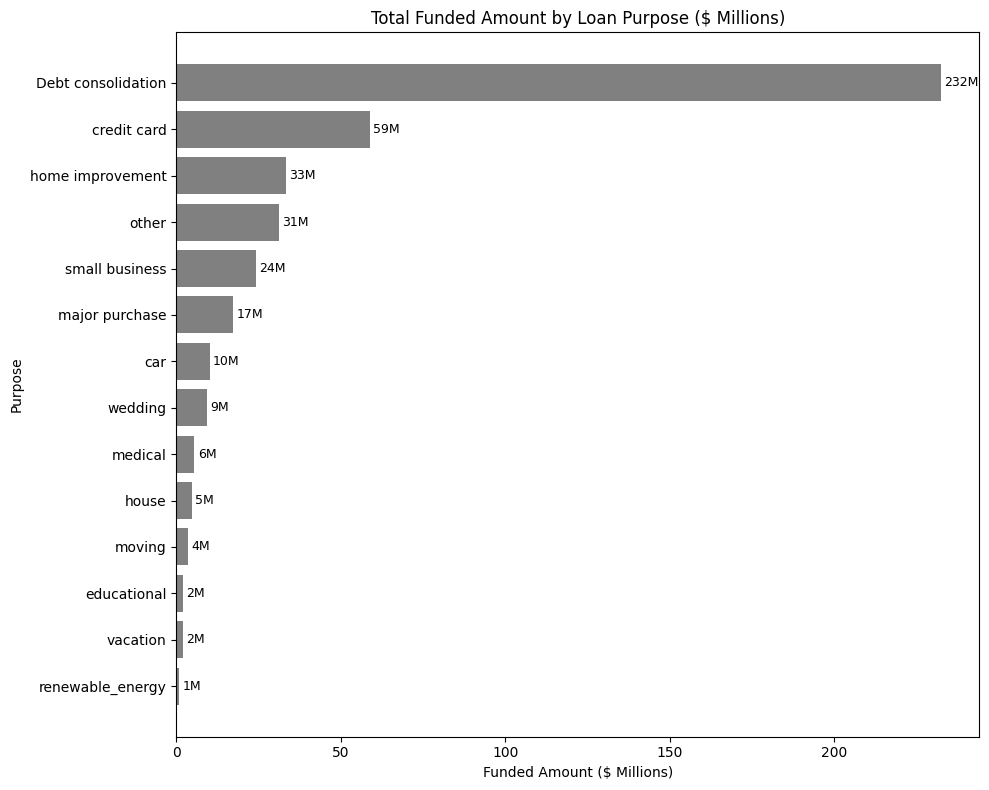

In [ ]:
funded_purpose= df.groupby('purpose')['loan_amount'].sum().sort_values()
funded_purpose_millions = funded_purpose/1000000

plt.figure(figsize= (10,8))
bars= plt.barh(funded_purpose_millions.index, funded_purpose_millions.values, color= 'gray')

for bar in bars:
    width= bar.get_width()
    plt.text(width+1, bar.get_y()+bar.get_height() /2, f"{width:.0f}M",ha="left", va='center',fontsize=9)

plt.title('Total Funded Amount by Loan Purpose ($ Millions)')
plt.xlabel('Funded Amount ($ Millions)')
plt.ylabel("Purpose")
plt.tight_layout()
plt.show()



In [ ]:
### Loan Purpose for Total Received Amount

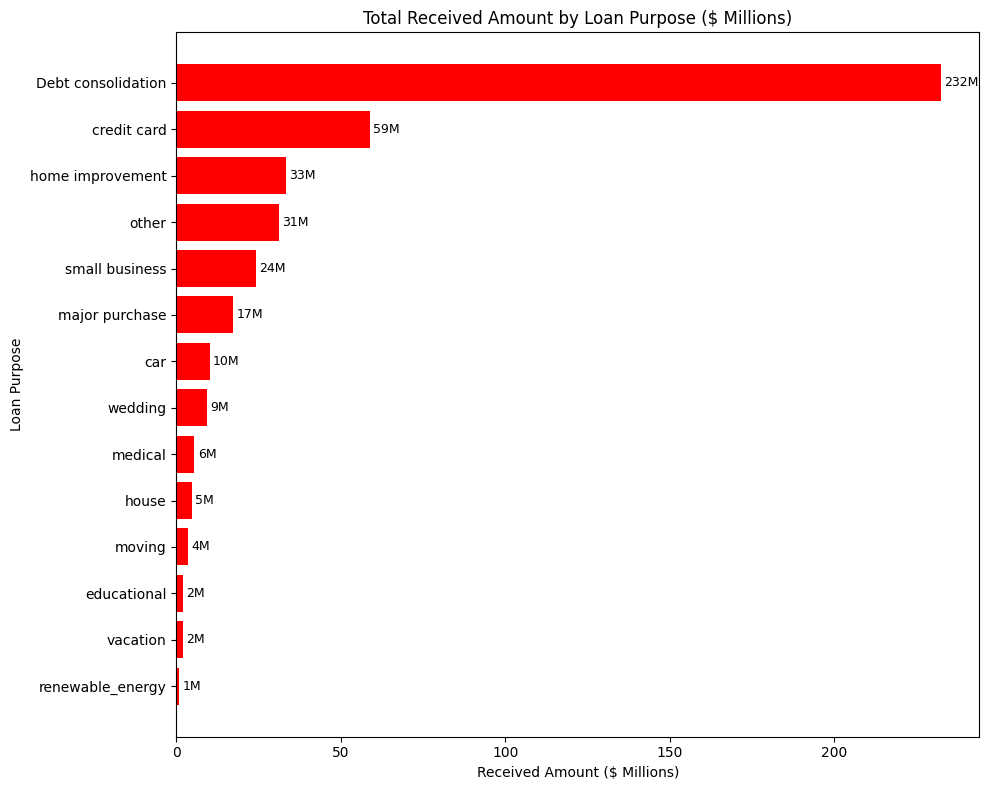

In [ ]:
received_amount_purpose= df.groupby('purpose')['loan_amount'].sum().sort_values()
received_amount_purpose_millions = received_amount_purpose/1000000

plt.figure(figsize= (10,8))
bars= plt.barh(received_amount_purpose_millions.index, received_amount_purpose_millions.values, color= 'red')

for bar in bars:
    width= bar.get_width()
    plt.text(width+1, bar.get_y()+bar.get_height() /2, f"{width:.0f}M",ha="left", va='center',fontsize=9)

plt.title('Total Received Amount by Loan Purpose ($ Millions)')
plt.xlabel('Received Amount ($ Millions)')
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()



In [ ]:
### Loan Purpose by Applications

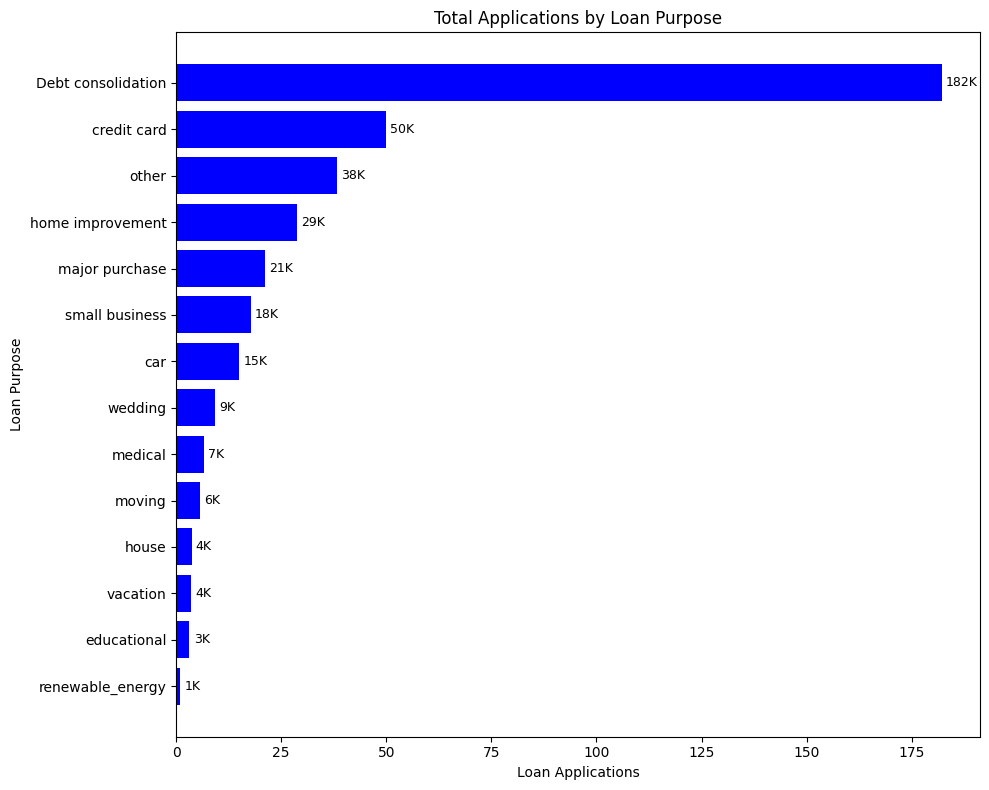

In [ ]:
# %%
total_applications_purpose= df.groupby('purpose')['id'].count().sort_values()
received_amount_purpose_thousands = total_applications_purpose/100

plt.figure(figsize= (10,8))
bars= plt.barh(received_amount_purpose_thousands.index, received_amount_purpose_thousands.values, color= 'blue')

for bar in bars:
    width= bar.get_width()
    plt.text(width+1, bar.get_y()+bar.get_height() /2, f"{width:.0f}K",ha="left", va='center',fontsize=9)

plt.title('Total Applications by Loan Purpose')
plt.xlabel('Loan Applications')
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()




In [ ]:
### Home Ownership Analysis for Total Funded Amount

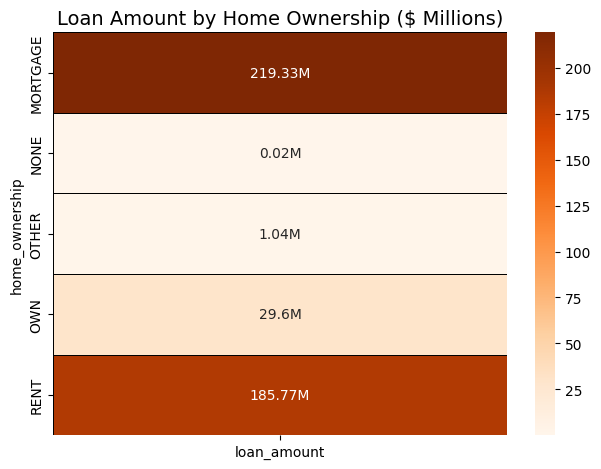

In [ ]:
home_funding = (
    df.groupby('home_ownership')['loan_amount']
      .sum()
      .div(1000000)
      .reset_index()
)
pivot_data = home_funding.set_index('home_ownership')
labels = pivot_data.round(2).astype(str) + "M"

sns.heatmap(
    pivot_data,
    annot=labels,
    fmt="",
    cmap='Oranges',
    linewidths=0.5,
    linecolor='k',
    annot_kws={"ha": "center", "va": "center"}
)

plt.title("Loan Amount by Home Ownership ($ Millions)", fontsize=14)
plt.xlabel("")
plt.tight_layout()
plt.show()



In [ ]:
### Home Ownership Analysis for Total Received Amount

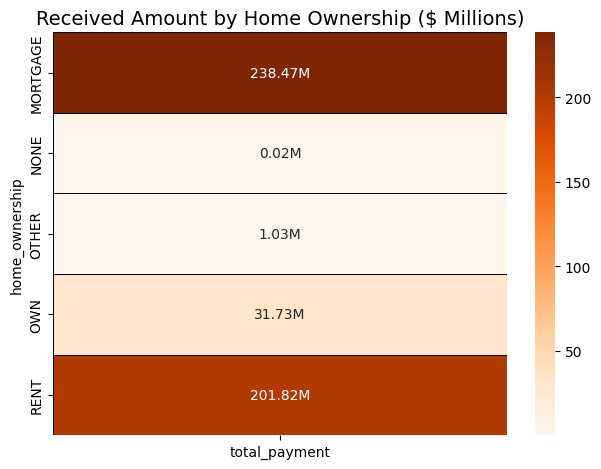

In [ ]:
home_received = (
    df.groupby('home_ownership')['total_payment']
      .sum()
      .div(1000000)
      .reset_index()
)
pivot_data = home_received.set_index('home_ownership')
labels = pivot_data.round(2).astype(str) + "M"

sns.heatmap(
    pivot_data,
    annot=labels,
    fmt="",
    cmap='Oranges',
    linewidths=0.5,
    linecolor='k',
    annot_kws={"ha": "center", "va": "center"}
)

plt.title("Received Amount by Home Ownership ($ Millions)", fontsize=14)
plt.xlabel("")
plt.tight_layout()
plt.show()



In [ ]:
### Home Ownership Analysis for Total Loan Applications

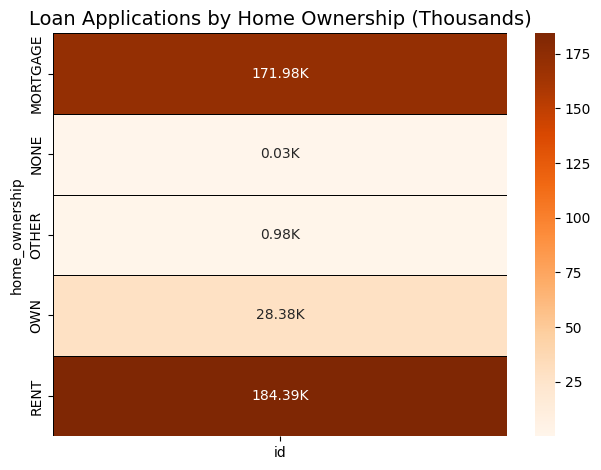

In [ ]:
home_applications = (
    df.groupby('home_ownership')['id']
      .count()
      .div(100)
      .reset_index()
)
pivot_data = home_applications.set_index('home_ownership')
labels = pivot_data.round(2).astype(str) + "K"

sns.heatmap(
    pivot_data,
    annot=labels,
    fmt="",
    cmap='Oranges',
    linewidths=0.5,
    linecolor='k',
    annot_kws={"ha": "center", "va": "center"}
)

plt.title("Loan Applications by Home Ownership (Thousands)", fontsize=14)
plt.xlabel("")
plt.tight_layout()
plt.show()

